In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
from torchvision import datasets,transforms
import os
from PIL import Image
from pathlib import Path

In [2]:
data_path = Path("data/")

In [3]:
data_path

WindowsPath('data')

In [4]:
dataset_path = data_path / "butterfly"

In [5]:
dataset_path

WindowsPath('data/butterfly')

In [6]:
train_dir = dataset_path / "train"
test_dir = dataset_path / "test"
val_dir = dataset_path / "valid"

In [7]:
train_dir

WindowsPath('data/butterfly/train')

In [8]:
from torch.utils.data import DataLoader

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4839305281639099, 0.467018187046051, 0.3432614505290985],
        std=[0.23302605748176575, 0.22729410231113434, 0.2211964726448059]
)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4839305281639099, 0.467018187046051, 0.3432614505290985],
        std=[0.23302605748176575, 0.22729410231113434, 0.2211964726448059]
)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4839305281639099, 0.467018187046051, 0.3432614505290985],
        std=[0.23302605748176575, 0.22729410231113434, 0.2211964726448059]
)
])

In [10]:
NUM_WORKERS = os.cpu_count()
#NUM_WORKERS = 0 # you can make this 0 if you get any error on mac silicon

def create_dataloaders(
    train_dir: str,
    test_dir: str,
    val_dir: str,
    train_transform: transforms.Compose,
    test_transform: transforms.Compose,
    val_transform: transforms.Compose,
    batch_size: int,
    num_workers: int=NUM_WORKERS
):
  # Use ImageFolder to create dataset(s)
  train_data = datasets.ImageFolder(train_dir, transform=train_transform)
  test_data = datasets.ImageFolder(test_dir, transform=test_transform)
  val_data = datasets.ImageFolder(val_dir, transform = val_transform)

  # Get class names
  class_names = train_data.classes

  # Turn images into data loaders
  train_dataloader = DataLoader(
      train_data,
      batch_size=batch_size,
      shuffle=True,
      num_workers=num_workers,
      pin_memory=True,
  )
  test_dataloader = DataLoader(
      test_data,
      batch_size=batch_size,
      shuffle=False, # don't need to shuffle test data
      num_workers=num_workers,
      pin_memory=True,
  )
  val_dataloader = DataLoader(
       val_data,
       batch_size = batch_size,
       shuffle=False,
       num_workers=num_workers,
       pin_memory=True
   )

  return train_dataloader, test_dataloader,val_dataloader, class_names

In [11]:
train_dataloader, test_dataloader,val_dataloader, class_names = create_dataloaders(train_dir =train_dir,
                                                                                    test_dir=test_dir,
                                                                                    val_dir = val_dir,
                                                                                    train_transform=train_transform,
                                                                                    test_transform=  test_transform,
                                                                                    val_transform = val_transform,
                                                                                    batch_size = 32)

In [12]:
len(class_names)

100

In [13]:
import torchvision

In [14]:
weights = torchvision.models.ResNet18_Weights.DEFAULT

In [15]:
weights

ResNet18_Weights.IMAGENET1K_V1

In [16]:
auto_transform = weights.transforms()

In [17]:
auto_transform

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [18]:
'''
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


def calculate_dataset_statistics(
    dataset_path,
    image_size=(224, 224),
    batch_size=32,
    num_workers=0,
):
    """
    Bir ImageFolder dataset'i için RGB mean ve std hesaplar.

    Args:
        dataset_path (str): Dataset klasör yolu.
        image_size (tuple): Resize edilecek boyut.
        batch_size (int): DataLoader batch size.
        num_workers (int): DataLoader worker sayısı.

    Returns:
        mean (Tensor)
        std (Tensor)
    """

    # Sadece Resize ve ToTensor uygulanır.
    # Normalize uygulanmaz!
    transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor()
    ])

    dataset = datasets.ImageFolder(
        root=dataset_path,
        transform=transform
    )

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )

    mean = torch.zeros(3)
    std = torch.zeros(3)
    total_images = 0

    for images, _ in dataloader:

        # (B,C,H,W) -> (B,C,H*W)
        images = images.view(images.size(0), images.size(1), -1)

        mean += images.mean(dim=2).sum(dim=0)
        std += images.std(dim=2).sum(dim=0)

        total_images += images.size(0)

    mean /= total_images
    std /= total_images

    print("=" * 50)
    print(f"Dataset Path : {dataset_path}")
    print(f"Toplam Resim : {len(dataset)}")
    print(f"Sınıflar     : {dataset.classes}")
    print(f"Image Size   : {image_size}")
    print("=" * 50)

    print("\nMean:")
    print(mean)

    print("\nStd:")
    print(std)

    print("\nKopyala-Yapıştır Normalize:")
    print(f"""
transforms.Normalize(
    mean={mean.tolist()},
    std={std.tolist()}
)
""")

    return mean, std
mean, std = calculate_dataset_statistics(
    "data/butterfly/train",
    image_size=(224,224)
)
# kullanım için data yolunu ve image_size değerini değiştirmek yeterli olur

'''

'\nimport torch\nfrom torch.utils.data import DataLoader\nfrom torchvision import datasets, transforms\n\n\ndef calculate_dataset_statistics(\n    dataset_path,\n    image_size=(224, 224),\n    batch_size=32,\n    num_workers=0,\n):\n    """\n    Bir ImageFolder dataset\'i için RGB mean ve std hesaplar.\n\n    Args:\n        dataset_path (str): Dataset klasör yolu.\n        image_size (tuple): Resize edilecek boyut.\n        batch_size (int): DataLoader batch size.\n        num_workers (int): DataLoader worker sayısı.\n\n    Returns:\n        mean (Tensor)\n        std (Tensor)\n    """\n\n    # Sadece Resize ve ToTensor uygulanır.\n    # Normalize uygulanmaz!\n    transform = transforms.Compose([\n        transforms.Resize(image_size),\n        transforms.ToTensor()\n    ])\n\n    dataset = datasets.ImageFolder(\n        root=dataset_path,\n        transform=transform\n    )\n\n    dataloader = DataLoader(\n        dataset,\n        batch_size=batch_size,\n        shuffle=False,\n    

In [19]:
torch.cuda.is_available()

True

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [21]:
device

'cuda'

In [22]:
model = torchvision.models.resnet18(weights=weights).to(device)

In [23]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [24]:
from torchinfo import summary

In [25]:
summary(model=model,
        input_size=(32,3,224,224),
        col_names = ["input_size","output_size",
"num_params",
"trainable",])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ResNet                                   [32, 3, 224, 224]         [32, 1000]                --                        True
├─Conv2d: 1-1                            [32, 3, 224, 224]         [32, 64, 112, 112]        9,408                     True
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        [32, 64, 112, 112]        128                       True
├─ReLU: 1-3                              [32, 64, 112, 112]        [32, 64, 112, 112]        --                        --
├─MaxPool2d: 1-4                         [32, 64, 112, 112]        [32, 64, 56, 56]          --                        --
├─Sequential: 1-5                        [32, 64, 56, 56]          [32, 64, 56, 56]          --                        True
│    └─BasicBlock: 2-1                   [32, 64, 56, 56]          [32, 64, 56, 56]          --                        True
│    │ 

In [26]:
# ResNet modellerde features yok o yüzden direkt parameters kullanarak kapatıyoruz

In [27]:
for param in model.parameters():
  param.requires_grad = False # öğrenebilen parametre

In [28]:
summary(model=model,
        input_size=(32,3,224,224),
        col_names = ["input_size","output_size",
"num_params",
"trainable",])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ResNet                                   [32, 3, 224, 224]         [32, 1000]                --                        False
├─Conv2d: 1-1                            [32, 3, 224, 224]         [32, 64, 112, 112]        (9,408)                   False
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        [32, 64, 112, 112]        (128)                     False
├─ReLU: 1-3                              [32, 64, 112, 112]        [32, 64, 112, 112]        --                        --
├─MaxPool2d: 1-4                         [32, 64, 112, 112]        [32, 64, 56, 56]          --                        --
├─Sequential: 1-5                        [32, 64, 56, 56]          [32, 64, 56, 56]          --                        False
│    └─BasicBlock: 2-1                   [32, 64, 56, 56]          [32, 64, 56, 56]          --                        False
│ 

In [29]:
model.fc = nn.Linear(model.fc.in_features, len(class_names))

In [30]:
summary(model=model,
        input_size=(32,3,224,224),
        col_names = ["input_size","output_size",
"num_params",
"trainable",])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ResNet                                   [32, 3, 224, 224]         [32, 100]                 --                        Partial
├─Conv2d: 1-1                            [32, 3, 224, 224]         [32, 64, 112, 112]        (9,408)                   False
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        [32, 64, 112, 112]        (128)                     False
├─ReLU: 1-3                              [32, 64, 112, 112]        [32, 64, 112, 112]        --                        --
├─MaxPool2d: 1-4                         [32, 64, 112, 112]        [32, 64, 56, 56]          --                        --
├─Sequential: 1-5                        [32, 64, 56, 56]          [32, 64, 56, 56]          --                        False
│    └─BasicBlock: 2-1                   [32, 64, 56, 56]          [32, 64, 56, 56]          --                        False


In [31]:
model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.3, inplace=True)
).to(device)

In [32]:
summary(model=model,
        input_size=(32,3,224,224),
        col_names = ["input_size","output_size",
"num_params",
"trainable",])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ResNet                                   [32, 3, 224, 224]         [32, 100]                 --                        Partial
├─Conv2d: 1-1                            [32, 3, 224, 224]         [32, 64, 112, 112]        (9,408)                   False
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        [32, 64, 112, 112]        (128)                     False
├─ReLU: 1-3                              [32, 64, 112, 112]        [32, 64, 112, 112]        --                        --
├─MaxPool2d: 1-4                         [32, 64, 112, 112]        [32, 64, 56, 56]          --                        --
├─Sequential: 1-5                        [32, 64, 56, 56]          [32, 64, 56, 56]          --                        False
│    └─BasicBlock: 2-1                   [32, 64, 56, 56]          [32, 64, 56, 56]          --                        False


In [33]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [34]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(),lr=0.001,weight_decay=0.0001)

In [37]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device : device):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):

        X = X.to(device)
        y = y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device : torch.device):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):

            X = X.to(device)
            y = y.to(device)
            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

def val_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device : torch.device):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    val_loss, val_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):

            X = X.to(device)
            y = y.to(device)
            # 1. Forward pass
            val_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(val_pred_logits, y)
            val_loss += loss.item()

            # Calculate and accumulate accuracy
            val_pred_labels = val_pred_logits.argmax(dim=1)
            val_acc += ((val_pred_labels == y).sum().item() / len(val_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    val_loss = val_loss / len(dataloader)
    val_acc = val_acc / len(dataloader)
    return val_loss, val_acc    


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          val_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          device : torch.device,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    # 2. Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "val_loss":[],
               "val_acc":[]
               }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device = device)
        val_loss, val_acc = val_step(model=model,
                                        dataloader=val_dataloader,
                                        loss_fn=loss_fn,
                                        device = device)


        # 4. Print out what's happening
        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["val_loss"].append(val_loss.item() if isinstance(val_loss, torch.Tensor) else val_loss)
        results["val_acc"].append(val_acc.item() if isinstance(val_acc, torch.Tensor) else val_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [38]:
results = train(model=model,
                train_dataloader=train_dataloader,
                val_dataloader=val_dataloader,
                optimizer = optimizer,
                loss_fn = loss_fn,
                device=device,
                epochs=10)

Epoch: 1 | train_loss: 0.8301 | train_acc: 0.8278 | val_loss: 0.5903 | val_acc: 0.8824
Epoch: 2 | train_loss: 0.6107 | train_acc: 0.8615 | val_loss: 0.5178 | val_acc: 0.8785
Epoch: 3 | train_loss: 0.4977 | train_acc: 0.8814 | val_loss: 0.4422 | val_acc: 0.9020
Epoch: 4 | train_loss: 0.4467 | train_acc: 0.8861 | val_loss: 0.4031 | val_acc: 0.9000
Epoch: 5 | train_loss: 0.4059 | train_acc: 0.8931 | val_loss: 0.4052 | val_acc: 0.9109
Epoch: 6 | train_loss: 0.3756 | train_acc: 0.8999 | val_loss: 0.4000 | val_acc: 0.8961
Epoch: 7 | train_loss: 0.3497 | train_acc: 0.9034 | val_loss: 0.3775 | val_acc: 0.9137
Epoch: 8 | train_loss: 0.3302 | train_acc: 0.9105 | val_loss: 0.3658 | val_acc: 0.9039
Epoch: 9 | train_loss: 0.3118 | train_acc: 0.9125 | val_loss: 0.3657 | val_acc: 0.9109
Epoch: 10 | train_loss: 0.2996 | train_acc: 0.9178 | val_loss: 0.3632 | val_acc: 0.9082


In [40]:
test_loss,test_acc = test_step(model = model,
                               dataloader = test_dataloader,
                               loss_fn = loss_fn,
                               device = device)

print(f"Final test loss: {test_loss}:.4f")
print(f"Final test accuracy: {test_acc}:.4f")

Final test loss: 0.3488988019526005:.4f
Final test accuracy: 0.8984375:.4f


In [41]:
from PIL import Image

In [42]:
from typing import Tuple, List

In [43]:
def transform_predict(model: nn.Module,
                      image_path: str,
                      class_names: List[str],
                      image_size: Tuple[int,int] = (224,224),
                      transform: torchvision.transforms = None,
                      device: torch.device = device):
    img = Image.open(image_path).convert("RGB")

    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.4839305281639099, 0.467018187046051, 0.3432614505290985],
        std=[0.23302605748176575, 0.22729410231113434, 0.2211964726448059])
        ])

    # Bu blok artık if/else'in DIŞINDA, her durumda çalışır
    model.to(device)
    model.eval()
    with torch.inference_mode():
        transformed_image = image_transform(img).unsqueeze(dim=0)
        target_image_pred = model(transformed_image.to(device))

    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]}, Prob: {target_image_pred_probs.max():.3f}")
    plt.axis("off")

In [44]:
class_names

['ADONIS',
 'AFRICAN GIANT SWALLOWTAIL',
 'AMERICAN SNOOT',
 'AN 88',
 'APPOLLO',
 'ARCIGERA FLOWER MOTH',
 'ATALA',
 'ATLAS MOTH',
 'BANDED ORANGE HELICONIAN',
 'BANDED PEACOCK',
 'BANDED TIGER MOTH',
 'BECKERS WHITE',
 'BIRD CHERRY ERMINE MOTH',
 'BLACK HAIRSTREAK',
 'BLUE MORPHO',
 'BLUE SPOTTED CROW',
 'BROOKES BIRDWING',
 'BROWN ARGUS',
 'BROWN SIPROETA',
 'CABBAGE WHITE',
 'CAIRNS BIRDWING',
 'CHALK HILL BLUE',
 'CHECQUERED SKIPPER',
 'CHESTNUT',
 'CINNABAR MOTH',
 'CLEARWING MOTH',
 'CLEOPATRA',
 'CLODIUS PARNASSIAN',
 'CLOUDED SULPHUR',
 'COMET MOTH',
 'COMMON BANDED AWL',
 'COMMON WOOD-NYMPH',
 'COPPER TAIL',
 'CRECENT',
 'CRIMSON PATCH',
 'DANAID EGGFLY',
 'EASTERN COMA',
 'EASTERN DAPPLE WHITE',
 'EASTERN PINE ELFIN',
 'ELBOWED PIERROT',
 'EMPEROR GUM MOTH',
 'GARDEN TIGER MOTH',
 'GIANT LEOPARD MOTH',
 'GLITTERING SAPPHIRE',
 'GOLD BANDED',
 'GREAT EGGFLY',
 'GREAT JAY',
 'GREEN CELLED CATTLEHEART',
 'GREEN HAIRSTREAK',
 'GREY HAIRSTREAK',
 'HERCULES MOTH',
 'HUMMING BIRD H

In [47]:
custom_image_path = data_path / "metalmark.jpg"

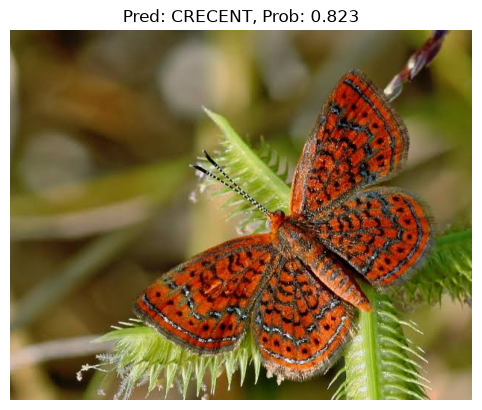

In [48]:
transform_predict(model,custom_image_path,class_names)

In [51]:
custom_image_path2 = data_path / "green_hairstreak.jpg"

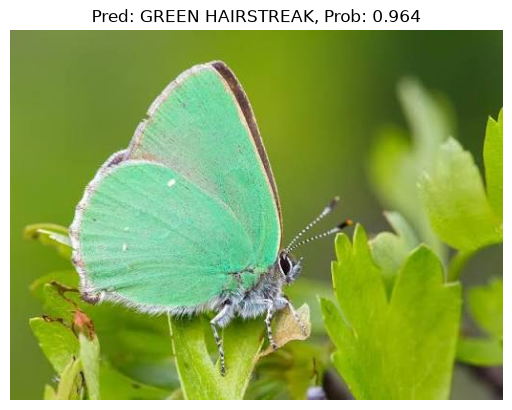

In [52]:
transform_predict(model,custom_image_path2,class_names)

In [54]:
custom_image_path3 = data_path / "banded_peacok.jpg"

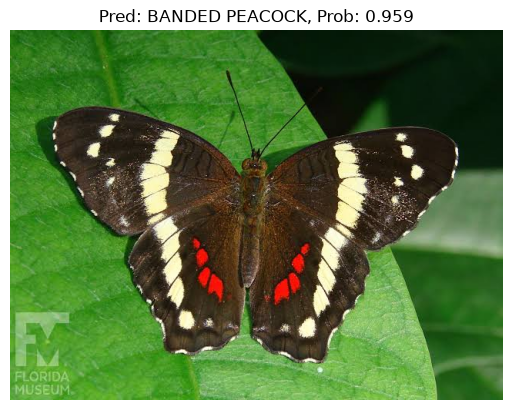

In [55]:
transform_predict(model,custom_image_path3,class_names)

In [56]:
custom_image_path = data_path / "man.jpg"

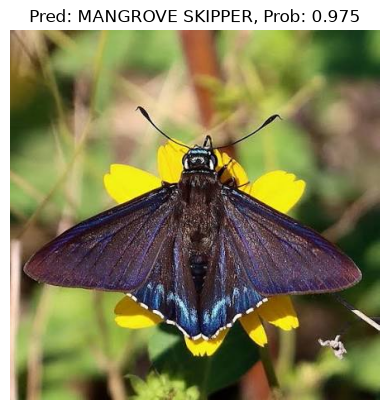

In [57]:
transform_predict(model,custom_image_path,class_names)